# 09f — Vina Local Rescoring and Interaction Refinement

## PEARL Pipeline 5

This notebook consumes the **selected receptor-bound DiffDock poses from 09e** and adds a
second, independent energetic layer using **AutoDock Vina**.

The purpose is deliberately limited:

```text
DiffDock selected pose
        ↓
Vina score of the unchanged pose
        ↓
short local Vina optimization
        ↓
Vina score after local optimization
        ↓
comparative energetic / pose-stability ranking
```

This is **not** rigorous binding free energy, MM/PBSA, MM/GBSA or experimental affinity.
Vina scores are empirical docking scores reported in kcal/mol-like units and are used here
only for **comparative ranking within the same receptor/protocol**.

### Why only the top four from 09e?

09e ranked the current rescue candidates as:

```text
1 MOL00273
2 MOL00583
3 MOL00600
4 MOL00484
...
```

The top four therefore move to the more expensive refinement layer.

All four remain:

```text
docking_track = NEAR_MISS_RESCUE
pharmacophore_status = NEAR_MISS_MANDATORY_ONLY
```

A favorable Vina score does **not** convert them into strict pharmacophore hits.


## 1. Scientific strategy

09f does **not** perform a new unconstrained global docking experiment.

Instead, it takes the pose selected by DiffDock and asks two narrower questions:

1. **How does Vina score the existing DiffDock pose?**
2. **Does a short local Vina optimization improve the score without requiring a new global
   search?**

This preserves the structural hypothesis produced in 09e while introducing an independent
empirical energetic criterion.

AutoDock Vina's Python API provides:

```python
v.score()
v.optimize()
```

where `score()` evaluates the current pose and `optimize()` performs a quick local BFGS
optimization.

The resulting values should be interpreted as **Vina scoring-function outputs**, not
thermodynamic ΔG.


In [1]:
from pathlib import Path
import json
import math
import shutil
import subprocess
import textwrap
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from rdkit import Chem
from rdkit.Chem import rdMolAlign

print("09f PEARL analysis environment loaded.")


09f PEARL analysis environment loaded.


## 2. Configuration


In [2]:
OUTPUTS_ROOT = Path("outputs")

# ======================================================
# Input from 09e
# ======================================================

INPUT_09E_ROOT = (
    OUTPUTS_ROOT
    / "pipeline_5_pharmacophore_09e_diffdock"
)

BEST_POSE_09E_PATH = (
    INPUT_09E_ROOT
    / "tables"
    / "09e_best_pose_per_candidate.csv"
)

SELECTED_POSE_FILES_09E_PATH = (
    INPUT_09E_ROOT
    / "tables"
    / "09e_selected_pose_files.csv"
)

QC_09E_PATH = (
    INPUT_09E_ROOT
    / "tables"
    / "09e_QC.csv"
)

RECEPTOR_09E_PATH = (
    INPUT_09E_ROOT
    / "inputs"
    / "09e_receptor_chain_B.pdb"
)

# ======================================================
# Candidate selection
# ======================================================

TOP_N_FOR_09F = 4

# ======================================================
# External Vina / Meeko stage
# ======================================================

RUN_EXISTING_VINA_RESULTS_ANALYSIS = True

# Use a separate external environment. The notebook only prepares
# inputs and analyses the CSV returned by that environment.
VINA_ENV_NAME = "pearl-vina"

# Padding added around the selected ligand pose to build Vina maps.
VINA_BOX_PADDING_A = 8.0
VINA_MIN_BOX_A = 20.0
VINA_MAX_BOX_A = 32.0

# Local optimization only; no global Vina docking search.
VINA_OPTIMIZE_MAX_STEPS = 0

# ======================================================
# 09f output
# ======================================================

OUTPUT_ROOT = (
    OUTPUTS_ROOT
    / "pipeline_5_pharmacophore_09f_vina_refinement"
)

INPUT_DIR = OUTPUT_ROOT / "inputs"
EXTERNAL_DIR = OUTPUT_ROOT / "vina_external"
TABLE_DIR = OUTPUT_ROOT / "tables"
STRUCTURE_DIR = OUTPUT_ROOT / "structures"
PLOT_DIR = OUTPUT_ROOT / "plots"
REPORT_DIR = OUTPUT_ROOT / "reports"

for d in [
    INPUT_DIR,
    EXTERNAL_DIR,
    TABLE_DIR,
    STRUCTURE_DIR,
    PLOT_DIR,
    REPORT_DIR,
]:
    d.mkdir(
        parents=True,
        exist_ok=True,
    )

VINA_RESULTS_CSV = (
    EXTERNAL_DIR
    / "09f_vina_local_rescoring_results.csv"
)

VINA_EXTERNAL_SCRIPT = (
    INPUT_DIR
    / "09f_run_vina_local_rescoring.py"
)

VINA_SHELL_SCRIPT = (
    INPUT_DIR
    / "09f_run_vina_local_rescoring.sh"
)

print("09e best poses:", BEST_POSE_09E_PATH)
print("09f output:", OUTPUT_ROOT)
print("Analyse existing Vina results:", RUN_EXISTING_VINA_RESULTS_ANALYSIS)


09e best poses: outputs/pipeline_5_pharmacophore_09e_diffdock/tables/09e_best_pose_per_candidate.csv
09f output: outputs/pipeline_5_pharmacophore_09f_vina_refinement
Analyse existing Vina results: True


## 3. Load and validate 09e production outputs


In [3]:
required_paths = [
    BEST_POSE_09E_PATH,
    SELECTED_POSE_FILES_09E_PATH,
    QC_09E_PATH,
    RECEPTOR_09E_PATH,
]

missing = [
    p
    for p in required_paths
    if not p.exists()
]

if missing:
    raise FileNotFoundError(
        "Missing required 09e outputs:\n"
        + "\n".join(
            str(p)
            for p in missing
        )
    )

best09e = pd.read_csv(
    BEST_POSE_09E_PATH
)

pose_files09e = pd.read_csv(
    SELECTED_POSE_FILES_09E_PATH
)

qc09e = pd.read_csv(
    QC_09E_PATH
)

qc_flags = (
    qc09e["pass"]
    .astype(str)
    .str.lower()
    .map({
        "true": True,
        "false": False,
    })
)

if qc_flags.isna().any():
    qc_flags = qc09e[
        "pass"
    ].astype(bool)

if not bool(
    qc_flags.all()
):
    raise RuntimeError(
        "09e technical QC did not pass completely."
    )

print(
    "09e candidates:",
    len(best09e),
)

display(
    best09e[
        [
            "09e_candidate_rank",
            "candidate_id",
            "docking_track",
            "pharmacophore_status",
            "chemistry_class",
            "pose_rank",
            "diffdock_confidence",
            "pose_support_score",
            "contacted_receptor_residues",
            "ligand_contact_fraction",
            "severe_clash",
        ]
    ]
)


09e candidates: 8


,09e_candidate_rank,candidate_id,docking_track,pharmacophore_status,chemistry_class,pose_rank,diffdock_confidence,pose_support_score,contacted_receptor_residues,ligand_contact_fraction,severe_clash
0,1,MOL00273,NEAR_MISS_RESCUE,NEAR_MISS_MANDATORY_ONLY,CHEM_PASS,1,-0.88,0.849855,7,0.826087,False
1,2,MOL00583,NEAR_MISS_RESCUE,NEAR_MISS_MANDATORY_ONLY,CHEM_PASS,1,-2.02,0.827007,12,0.933333,False
2,3,MOL00600,NEAR_MISS_RESCUE,NEAR_MISS_MANDATORY_ONLY,CHEM_PASS,4,-1.89,0.794880,9,0.911765,False
3,4,MOL00484,NEAR_MISS_RESCUE,NEAR_MISS_MANDATORY_ONLY,CHEM_PASS,4,-3.00,0.770340,14,1.000000,False
4,5,MOL00857,NEAR_MISS_RESCUE,NEAR_MISS_MANDATORY_ONLY,CHEM_PASS,3,-2.97,0.692047,12,0.781250,False
5,6,MOL00053,NEAR_MISS_RESCUE,NEAR_MISS_MANDATORY_ONLY,CHEM_PASS,3,-2.73,0.644268,9,0.652174,False
6,7,MOL00489,NEAR_MISS_RESCUE,NEAR_MISS_MANDATORY_ONLY,CHEM_PASS,3,-2.33,0.641926,7,0.586207,False
7,8,MOL00294,NEAR_MISS_RESCUE,NEAR_MISS_MANDATORY_ONLY,CHEM_PASS,10,-5.97,0.030612,0,0.000000,False


## 4. Select the top four 09e candidates

Selection is made strictly from `09e_candidate_rank`; no new weights are introduced here.


In [4]:
selected09f = (
    best09e
    .sort_values(
        "09e_candidate_rank",
        ascending=True,
    )
    .head(
        TOP_N_FOR_09F
    )
    .copy()
)

selected09f = selected09f.merge(
    pose_files09e[
        [
            "candidate_id",
            "selected_pose",
            "copied",
        ]
    ],
    on="candidate_id",
    how="left",
)

if selected09f[
    "selected_pose"
].isna().any():
    raise RuntimeError(
        "Missing selected 09e pose path for one or more candidates."
    )

if not selected09f[
    "copied"
].astype(bool).all():
    raise RuntimeError(
        "One or more 09e selected pose structures were not copied successfully."
    )

print(
    "09f selected candidates:",
    list(
        selected09f[
            "candidate_id"
        ]
    ),
)

display(
    selected09f[
        [
            "09e_candidate_rank",
            "candidate_id",
            "pose_rank",
            "diffdock_confidence",
            "pose_support_score",
            "selected_pose",
        ]
    ]
)


09f selected candidates: ['MOL00273', 'MOL00583', 'MOL00600', 'MOL00484']


,09e_candidate_rank,candidate_id,pose_rank,diffdock_confidence,pose_support_score,selected_pose
0,1,MOL00273,1,-0.88,0.849855,outputs/pipeline_5_pharmacophore_09e_diffdock/...
1,2,MOL00583,1,-2.02,0.827007,outputs/pipeline_5_pharmacophore_09e_diffdock/...
2,3,MOL00600,4,-1.89,0.794880,outputs/pipeline_5_pharmacophore_09e_diffdock/...
3,4,MOL00484,4,-3.00,0.770340,outputs/pipeline_5_pharmacophore_09e_diffdock/...


## 5. Prepare hydrogenated SDF files while preserving DiffDock heavy-atom coordinates

Meeko ligand preparation expects explicit hydrogens and 3D coordinates.

RDKit `AddHs(addCoords=True)` is used here only to add hydrogen coordinates. Heavy-atom
coordinates from the selected DiffDock pose are preserved.


In [5]:
prepared_rows = []

for row in selected09f.itertuples():
    src = Path(
        row.selected_pose
    )

    if not src.exists():
        raise FileNotFoundError(
            f"Selected pose missing: {src}"
        )

    supplier = Chem.SDMolSupplier(
        str(src),
        removeHs=False,
        sanitize=True,
    )

    mol = next(
        (
            m
            for m in supplier
            if m is not None
        ),
        None,
    )

    if mol is None:
        raise RuntimeError(
            f"Could not read {src}"
        )

    heavy_before = mol.GetNumHeavyAtoms()

    mol_h = Chem.AddHs(
        mol,
        addCoords=True,
    )

    dst = (
        INPUT_DIR
        / f"{row.candidate_id}_diffdock_pose_H.sdf"
    )

    writer = Chem.SDWriter(
        str(dst)
    )

    mol_h.SetProp(
        "_Name",
        str(
            row.candidate_id
        ),
    )

    mol_h.SetProp(
        "source",
        "09e_selected_DiffDock_pose",
    )

    writer.write(
        mol_h
    )

    writer.close()

    prepared_rows.append({
        "candidate_id": row.candidate_id,
        "input_sdf": str(
            dst.resolve()
        ),
        "heavy_atoms": heavy_before,
        "total_atoms_with_H": mol_h.GetNumAtoms(),
    })

prepared_df = pd.DataFrame(
    prepared_rows
)

display(
    prepared_df
)

prepared_df.to_csv(
    TABLE_DIR
    / "09f_prepared_ligand_inputs.csv",
    index=False,
)


,candidate_id,input_sdf,heavy_atoms,total_atoms_with_H
0,MOL00273,/Users/robertobruzzese/Desktop/venv/outputs/pi...,23,35
1,MOL00583,/Users/robertobruzzese/Desktop/venv/outputs/pi...,30,53
2,MOL00600,/Users/robertobruzzese/Desktop/venv/outputs/pi...,34,70
3,MOL00484,/Users/robertobruzzese/Desktop/venv/outputs/pi...,25,46


## 6. Copy the receptor into the stable 09f input directory


In [6]:
RECEPTOR_09F_PATH = (
    INPUT_DIR
    / "09f_receptor_chain_B.pdb"
)

shutil.copy2(
    RECEPTOR_09E_PATH,
    RECEPTOR_09F_PATH,
)

print(
    "Receptor:",
    RECEPTOR_09F_PATH.resolve(),
)


Receptor: /Users/robertobruzzese/Desktop/venv/outputs/pipeline_5_pharmacophore_09f_vina_refinement/inputs/09f_receptor_chain_B.pdb


## 7. Create the external Vina / Meeko manifest


In [7]:
manifest = selected09f.merge(
    prepared_df,
    on="candidate_id",
    how="left",
)

manifest[
    "receptor_pdb"
] = str(
    RECEPTOR_09F_PATH.resolve()
)

manifest_path = (
    INPUT_DIR
    / "09f_vina_manifest.csv"
)

manifest.to_csv(
    manifest_path,
    index=False,
)

print(
    "Manifest:",
    manifest_path.resolve(),
)

display(
    manifest[
        [
            "candidate_id",
            "09e_candidate_rank",
            "diffdock_confidence",
            "pose_support_score",
            "input_sdf",
        ]
    ]
)


Manifest: /Users/robertobruzzese/Desktop/venv/outputs/pipeline_5_pharmacophore_09f_vina_refinement/inputs/09f_vina_manifest.csv


,candidate_id,09e_candidate_rank,diffdock_confidence,pose_support_score,input_sdf
0,MOL00273,1,-0.88,0.849855,/Users/robertobruzzese/Desktop/venv/outputs/pi...
1,MOL00583,2,-2.02,0.827007,/Users/robertobruzzese/Desktop/venv/outputs/pi...
2,MOL00600,3,-1.89,0.794880,/Users/robertobruzzese/Desktop/venv/outputs/pi...
3,MOL00484,4,-3.00,0.770340,/Users/robertobruzzese/Desktop/venv/outputs/pi...


## 8. Generate the external AutoDock Vina rescoring script

The generated script performs, for each selected candidate:

```text
1. prepare receptor PDBQT with Meeko
2. prepare the hydrogenated DiffDock ligand pose as PDBQT
3. create a Vina map box around that exact pose
4. v.score()    → score of unchanged DiffDock pose
5. v.optimize() → short local BFGS optimization
6. save locally optimized pose
7. export minimized pose back to SDF when Meeko export is available
8. write all score components to CSV
```

No `v.dock()` call is made.


In [8]:
external_script_text = r'''
from pathlib import Path
import csv
import subprocess
import sys

import numpy as np
import pandas as pd
from rdkit import Chem
from vina import Vina

MANIFEST = Path(r"__MANIFEST__")
OUT_DIR = Path(r"__OUT_DIR__")
RESULTS_CSV = Path(r"__RESULTS__")
PADDING = __PADDING__
MIN_BOX = __MIN_BOX__
MAX_BOX = __MAX_BOX__
MAX_STEPS = __MAX_STEPS__

OUT_DIR.mkdir(parents=True, exist_ok=True)

manifest = pd.read_csv(MANIFEST)

receptor_pdb = Path(manifest.iloc[0]["receptor_pdb"])
receptor_base = OUT_DIR / "09f_receptor_chain_B"
receptor_pdbqt = receptor_base.with_suffix(".pdbqt")

if not receptor_pdbqt.exists():
    cmd = [
        "mk_prepare_receptor.py",
        "--read_pdb",
        str(receptor_pdb),
        "-o",
        str(receptor_base),
        "-p",
    ]
    print("Preparing receptor:", " ".join(cmd), flush=True)
    subprocess.run(cmd, check=True)

def ligand_box_from_sdf(sdf_path):
    supplier = Chem.SDMolSupplier(
        str(sdf_path),
        removeHs=False,
        sanitize=True,
    )
    mol = next((m for m in supplier if m is not None), None)
    if mol is None:
        raise RuntimeError(f"Cannot read ligand SDF: {sdf_path}")

    conf = mol.GetConformer()
    xyz = []
    for atom in mol.GetAtoms():
        if atom.GetAtomicNum() == 1:
            continue
        p = conf.GetAtomPosition(atom.GetIdx())
        xyz.append([p.x, p.y, p.z])

    xyz = np.asarray(xyz, dtype=float)
    lo = xyz.min(axis=0)
    hi = xyz.max(axis=0)
    center = (lo + hi) / 2.0
    size = (hi - lo) + 2.0 * PADDING
    size = np.clip(size, MIN_BOX, MAX_BOX)
    return center.tolist(), size.tolist()

rows = []

for rec in manifest.to_dict(orient="records"):
    cid = str(rec["candidate_id"])
    sdf = Path(rec["input_sdf"])
    ligand_pdbqt = OUT_DIR / f"{cid}_diffdock_pose.pdbqt"
    minimized_pdbqt = OUT_DIR / f"{cid}_vina_local_minimized.pdbqt"
    minimized_sdf = OUT_DIR / f"{cid}_vina_local_minimized.sdf"

    cmd = [
        "mk_prepare_ligand.py",
        "-i",
        str(sdf),
        "-o",
        str(ligand_pdbqt),
    ]

    print(f"\n[{cid}] Preparing ligand", flush=True)
    subprocess.run(cmd, check=True)

    center, box_size = ligand_box_from_sdf(sdf)

    v = Vina(
        sf_name="vina",
        cpu=0,
        seed=20260817,
        no_refine=False,
        verbosity=1,
    )

    v.set_receptor(
        str(receptor_pdbqt)
    )

    v.set_ligand_from_file(
        str(ligand_pdbqt)
    )

    v.compute_vina_maps(
        center=center,
        box_size=box_size,
    )

    score_before = np.asarray(
        v.score(),
        dtype=float,
    )

    score_after = np.asarray(
        v.optimize(
            max_steps=MAX_STEPS
        ),
        dtype=float,
    )

    v.write_pose(
        str(minimized_pdbqt),
        overwrite=True,
    )

    export_ok = False

    try:
        subprocess.run(
            [
                "mk_export.py",
                str(minimized_pdbqt),
                "-s",
                str(minimized_sdf),
            ],
            check=True,
        )
        export_ok = minimized_sdf.exists()
    except Exception as exc:
        print(
            f"[{cid}] SDF export warning: {exc}",
            flush=True,
        )

    # Vina/Vinardo score columns:
    # total, lig_inter, flex_inter, other_inter,
    # flex_intra, lig_intra, torsions, lig_intra_best_pose
    row = {
        "candidate_id": cid,
        "vina_score_before": float(score_before[0]),
        "vina_lig_inter_before": float(score_before[1]),
        "vina_lig_intra_before": float(score_before[5]),
        "vina_torsions_before": float(score_before[6]),
        "vina_score_after": float(score_after[0]),
        "vina_lig_inter_after": float(score_after[1]),
        "vina_lig_intra_after": float(score_after[5]),
        "vina_torsions_after": float(score_after[6]),
        "vina_delta_local_optimization": float(
            score_after[0] - score_before[0]
        ),
        "box_center_x": float(center[0]),
        "box_center_y": float(center[1]),
        "box_center_z": float(center[2]),
        "box_size_x": float(box_size[0]),
        "box_size_y": float(box_size[1]),
        "box_size_z": float(box_size[2]),
        "input_pdbqt": str(ligand_pdbqt),
        "minimized_pdbqt": str(minimized_pdbqt),
        "minimized_sdf": str(minimized_sdf),
        "minimized_sdf_exported": bool(export_ok),
    }

    rows.append(row)

    print(
        f"[{cid}] score before = {row['vina_score_before']:.3f}; "
        f"after = {row['vina_score_after']:.3f}; "
        f"delta = {row['vina_delta_local_optimization']:.3f}",
        flush=True,
    )

pd.DataFrame(rows).to_csv(
    RESULTS_CSV,
    index=False,
)

print(
    "\nVina rescoring complete:",
    RESULTS_CSV,
    flush=True,
)
'''

external_script_text = (
    external_script_text
    .replace(
        "__MANIFEST__",
        str(
            manifest_path.resolve()
        ),
    )
    .replace(
        "__OUT_DIR__",
        str(
            EXTERNAL_DIR.resolve()
        ),
    )
    .replace(
        "__RESULTS__",
        str(
            VINA_RESULTS_CSV.resolve()
        ),
    )
    .replace(
        "__PADDING__",
        str(
            float(
                VINA_BOX_PADDING_A
            )
        ),
    )
    .replace(
        "__MIN_BOX__",
        str(
            float(
                VINA_MIN_BOX_A
            )
        ),
    )
    .replace(
        "__MAX_BOX__",
        str(
            float(
                VINA_MAX_BOX_A
            )
        ),
    )
    .replace(
        "__MAX_STEPS__",
        str(
            int(
                VINA_OPTIMIZE_MAX_STEPS
            )
        ),
    )
)

VINA_EXTERNAL_SCRIPT.write_text(
    external_script_text,
    encoding="utf-8",
)

print(
    "External Python script:",
    VINA_EXTERNAL_SCRIPT.resolve(),
)


External Python script: /Users/robertobruzzese/Desktop/venv/outputs/pipeline_5_pharmacophore_09f_vina_refinement/inputs/09f_run_vina_local_rescoring.py


## 9. Generate a one-command shell launcher

The external environment should contain:

```text
vina
meeko
rdkit
pandas
numpy
```

The shell launcher activates `pearl-vina` and executes the generated Python script.


In [9]:
shell_text = f'''#!/bin/bash
set -e

source "$(conda info --base)/etc/profile.d/conda.sh"
conda activate {VINA_ENV_NAME}

python "{VINA_EXTERNAL_SCRIPT.resolve()}"
'''

VINA_SHELL_SCRIPT.write_text(
    shell_text,
    encoding="utf-8",
)

VINA_SHELL_SCRIPT.chmod(
    0o755
)

print(
    "Run script:",
    VINA_SHELL_SCRIPT.resolve(),
)

print()
print(
    shell_text
)


Run script: /Users/robertobruzzese/Desktop/venv/outputs/pipeline_5_pharmacophore_09f_vina_refinement/inputs/09f_run_vina_local_rescoring.sh

#!/bin/bash
set -e

source "$(conda info --base)/etc/profile.d/conda.sh"
conda activate pearl-vina

python "/Users/robertobruzzese/Desktop/venv/outputs/pipeline_5_pharmacophore_09f_vina_refinement/inputs/09f_run_vina_local_rescoring.py"



## 10. Stage-A status

For the first execution leave:

```python
RUN_EXISTING_VINA_RESULTS_ANALYSIS = False
```

After running the external script successfully, change it to `True` and run the notebook again.


In [10]:
print(
    "Vina results already present:",
    VINA_RESULTS_CSV.exists(),
)

if not RUN_EXISTING_VINA_RESULTS_ANALYSIS:
    print()
    print(
        "STAGE A COMPLETE."
    )
    print(
        "Run the generated Vina shell script externally."
    )
    print(
        "Then set RUN_EXISTING_VINA_RESULTS_ANALYSIS = True "
        "and rerun this notebook."
    )


Vina results already present: True


# Stage B — Vina energetic refinement analysis


## 11. Load Vina local-rescoring results


In [11]:
if RUN_EXISTING_VINA_RESULTS_ANALYSIS:
    if not VINA_RESULTS_CSV.exists():
        raise FileNotFoundError(
            "Vina results CSV not found. "
            "Run the external 09f script first."
        )

    vina_df = pd.read_csv(
        VINA_RESULTS_CSV
    )

    expected_ids = set(
        selected09f[
            "candidate_id"
        ].astype(str)
    )

    observed_ids = set(
        vina_df[
            "candidate_id"
        ].astype(str)
    )

    if expected_ids != observed_ids:
        raise RuntimeError(
            "Vina candidate set does not match the 09f selection."
        )

    print(
        "Vina candidates analysed:",
        len(vina_df),
    )

    display(
        vina_df[
            [
                "candidate_id",
                "vina_score_before",
                "vina_score_after",
                "vina_delta_local_optimization",
                "vina_lig_inter_before",
                "vina_lig_inter_after",
            ]
        ]
    )


Vina candidates analysed: 4


,candidate_id,vina_score_before,vina_score_after,vina_delta_local_optimization,vina_lig_inter_before,vina_lig_inter_after
0,MOL00273,-2.982,-3.937,-0.955,-4.115,-5.433
1,MOL00583,0.384,-4.314,-4.698,0.518,-5.827
2,MOL00600,1.998,-5.791,-7.789,2.523,-7.315
3,MOL00484,-0.556,-4.267,-3.711,-0.719,-5.514


## 12. Merge Vina energies with 09e structural evidence

The Vina score is kept separate from:

- DiffDock confidence;
- 09e pose-support score;
- contact-residue count;
- pharmacophore provenance.

This avoids pretending that heterogeneous scores are physically interchangeable.


In [12]:
if RUN_EXISTING_VINA_RESULTS_ANALYSIS:
    merge_cols = [
        "candidate_id",
        "09e_candidate_rank",
        "docking_track",
        "pharmacophore_status",
        "chemistry_class",
        "mandatory_rmsd_A",
        "chemistry_priority_score",
        "pose_rank",
        "diffdock_confidence",
        "pose_support_score",
        "contacted_receptor_residues",
        "ligand_contact_fraction",
        "severe_clash",
        "selected_pose",
    ]

    refined_df = selected09f[
        merge_cols
    ].merge(
        vina_df,
        on="candidate_id",
        how="inner",
    )

    refined_df[
        "local_optimization_improved"
    ] = (
        refined_df[
            "vina_score_after"
        ]
        <
        refined_df[
            "vina_score_before"
        ]
    )

    refined_df[
        "absolute_local_score_change"
    ] = (
        refined_df[
            "vina_delta_local_optimization"
        ].abs()
    )

    display(
        refined_df[
            [
                "candidate_id",
                "09e_candidate_rank",
                "diffdock_confidence",
                "pose_support_score",
                "vina_score_before",
                "vina_score_after",
                "vina_delta_local_optimization",
                "local_optimization_improved",
            ]
        ]
    )


,candidate_id,09e_candidate_rank,diffdock_confidence,pose_support_score,vina_score_before,vina_score_after,vina_delta_local_optimization,local_optimization_improved
0,MOL00273,1,-0.88,0.849855,-2.982,-3.937,-0.955,True
1,MOL00583,2,-2.02,0.827007,0.384,-4.314,-4.698,True
2,MOL00600,3,-1.89,0.794880,1.998,-5.791,-7.789,True
3,MOL00484,4,-3.00,0.770340,-0.556,-4.267,-3.711,True


## 13. Vina ranking

More negative Vina scores are ranked as more favorable **within this one protocol**.

Two rankings are retained:

```text
vina_pre_refinement_rank
vina_post_refinement_rank
```

The post-refinement rank is the primary 09f energetic ranking.


In [13]:
if RUN_EXISTING_VINA_RESULTS_ANALYSIS:
    refined_df[
        "vina_pre_refinement_rank"
    ] = refined_df[
        "vina_score_before"
    ].rank(
        method="min",
        ascending=True,
    ).astype(int)

    refined_df[
        "vina_post_refinement_rank"
    ] = refined_df[
        "vina_score_after"
    ].rank(
        method="min",
        ascending=True,
    ).astype(int)

    refined_df = refined_df.sort_values(
        [
            "vina_post_refinement_rank",
            "09e_candidate_rank",
        ],
        ascending=[
            True,
            True,
        ],
    ).reset_index(
        drop=True
    )

    refined_df.insert(
        0,
        "09f_rank",
        np.arange(
            1,
            len(refined_df) + 1,
        ),
    )

    refined_df.to_csv(
        TABLE_DIR
        / "09f_vina_refined_ranking.csv",
        index=False,
    )

    display(
        refined_df[
            [
                "09f_rank",
                "candidate_id",
                "vina_pre_refinement_rank",
                "vina_post_refinement_rank",
                "vina_score_before",
                "vina_score_after",
                "vina_delta_local_optimization",
                "09e_candidate_rank",
                "pose_support_score",
            ]
        ]
    )


,09f_rank,candidate_id,vina_pre_refinement_rank,vina_post_refinement_rank,vina_score_before,vina_score_after,vina_delta_local_optimization,09e_candidate_rank,pose_support_score
0,1,MOL00600,4,1,1.998,-5.791,-7.789,3,0.794880
1,2,MOL00583,3,2,0.384,-4.314,-4.698,2,0.827007
2,3,MOL00484,2,3,-0.556,-4.267,-3.711,4,0.770340
3,4,MOL00273,1,4,-2.982,-3.937,-0.955,1,0.849855


## 14. Cross-method convergence table

Rather than collapse everything into one universal score, 09f reports whether methods agree.


In [14]:
if RUN_EXISTING_VINA_RESULTS_ANALYSIS:
    convergence_df = refined_df[
        [
            "candidate_id",
            "09e_candidate_rank",
            "vina_pre_refinement_rank",
            "vina_post_refinement_rank",
            "diffdock_confidence",
            "pose_support_score",
            "vina_score_before",
            "vina_score_after",
            "contacted_receptor_residues",
            "ligand_contact_fraction",
            "chemistry_priority_score",
            "pharmacophore_status",
            "docking_track",
        ]
    ].copy()

    convergence_df[
        "rank_shift_09e_to_09f"
    ] = (
        convergence_df[
            "vina_post_refinement_rank"
        ]
        -
        convergence_df[
            "09e_candidate_rank"
        ]
    )

    convergence_df.to_csv(
        TABLE_DIR
        / "09f_cross_method_convergence.csv",
        index=False,
    )

    display(
        convergence_df
    )


,candidate_id,09e_candidate_rank,vina_pre_refinement_rank,vina_post_refinement_rank,diffdock_confidence,pose_support_score,vina_score_before,vina_score_after,contacted_receptor_residues,ligand_contact_fraction,chemistry_priority_score,pharmacophore_status,docking_track,rank_shift_09e_to_09f
0,MOL00600,3,4,1,-1.89,0.794880,1.998,-5.791,9,0.911765,3.902629,NEAR_MISS_MANDATORY_ONLY,NEAR_MISS_RESCUE,-2
1,MOL00583,2,3,2,-2.02,0.827007,0.384,-4.314,12,0.933333,3.781209,NEAR_MISS_MANDATORY_ONLY,NEAR_MISS_RESCUE,0
2,MOL00484,4,2,3,-3.00,0.770340,-0.556,-4.267,14,1.000000,4.341909,NEAR_MISS_MANDATORY_ONLY,NEAR_MISS_RESCUE,-1
3,MOL00273,1,1,4,-0.88,0.849855,-2.982,-3.937,7,0.826087,3.926745,NEAR_MISS_MANDATORY_ONLY,NEAR_MISS_RESCUE,3


## 15. Optional structural displacement after Vina local optimization

When Meeko successfully exports the minimized SDF, the notebook attempts a heavy-atom RMSD
between the original selected DiffDock pose and the locally minimized Vina pose.

This is a descriptive measure of how much local refinement moved the ligand.


In [15]:
def heavy_atom_rmsd_from_sdfs(
    sdf_a,
    sdf_b,
):
    sup_a = Chem.SDMolSupplier(
        str(sdf_a),
        removeHs=True,
        sanitize=True,
    )

    sup_b = Chem.SDMolSupplier(
        str(sdf_b),
        removeHs=True,
        sanitize=True,
    )

    mol_a = next(
        (
            m
            for m in sup_a
            if m is not None
        ),
        None,
    )

    mol_b = next(
        (
            m
            for m in sup_b
            if m is not None
        ),
        None,
    )

    if mol_a is None or mol_b is None:
        return np.nan

    if mol_a.GetNumHeavyAtoms() != mol_b.GetNumHeavyAtoms():
        return np.nan

    try:
        return float(
            rdMolAlign.GetBestRMS(
                mol_a,
                mol_b,
            )
        )
    except Exception:
        return np.nan

if RUN_EXISTING_VINA_RESULTS_ANALYSIS:
    rmsd_values = []

    for row in refined_df.itertuples():
        minimized_sdf = Path(
            row.minimized_sdf
        )

        if not minimized_sdf.exists():
            rmsd_values.append(
                np.nan
            )
            continue

        rmsd_values.append(
            heavy_atom_rmsd_from_sdfs(
                Path(
                    row.selected_pose
                ),
                minimized_sdf,
            )
        )

    refined_df[
        "diffdock_to_vina_local_RMSD_A"
    ] = rmsd_values

    refined_df.to_csv(
        TABLE_DIR
        / "09f_vina_refined_ranking.csv",
        index=False,
    )

    display(
        refined_df[
            [
                "candidate_id",
                "vina_score_before",
                "vina_score_after",
                "diffdock_to_vina_local_RMSD_A",
            ]
        ]
    )


,candidate_id,vina_score_before,vina_score_after,diffdock_to_vina_local_RMSD_A
0,MOL00600,1.998,-5.791,0.189987
1,MOL00583,0.384,-4.314,0.586386
2,MOL00484,-0.556,-4.267,0.056771
3,MOL00273,-2.982,-3.937,0.203004


## 16. Diagnostic plots


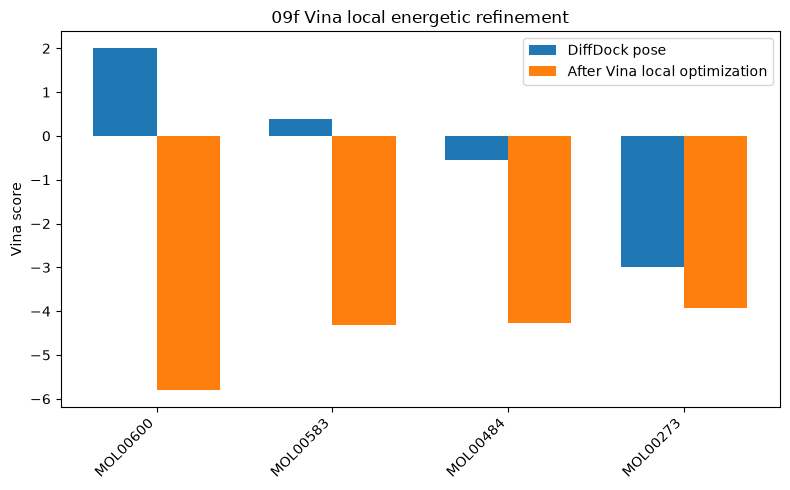

Saved: outputs/pipeline_5_pharmacophore_09f_vina_refinement/plots/09f_vina_before_after_scores.png


In [16]:
if RUN_EXISTING_VINA_RESULTS_ANALYSIS:
    plot_df = refined_df.sort_values(
        "09f_rank"
    )

    x = np.arange(
        len(plot_df)
    )

    width = 0.36

    plt.figure(
        figsize=(8, 5)
    )

    plt.bar(
        x - width / 2,
        plot_df[
            "vina_score_before"
        ],
        width=width,
        label="DiffDock pose",
    )

    plt.bar(
        x + width / 2,
        plot_df[
            "vina_score_after"
        ],
        width=width,
        label="After Vina local optimization",
    )

    plt.xticks(
        x,
        plot_df[
            "candidate_id"
        ],
        rotation=45,
        ha="right",
    )

    plt.ylabel(
        "Vina score"
    )

    plt.title(
        "09f Vina local energetic refinement"
    )

    plt.legend()

    plt.tight_layout()

    path = (
        PLOT_DIR
        / "09f_vina_before_after_scores.png"
    )

    plt.savefig(
        path,
        dpi=250,
        bbox_inches="tight",
    )

    plt.show()

    print(
        "Saved:",
        path,
    )


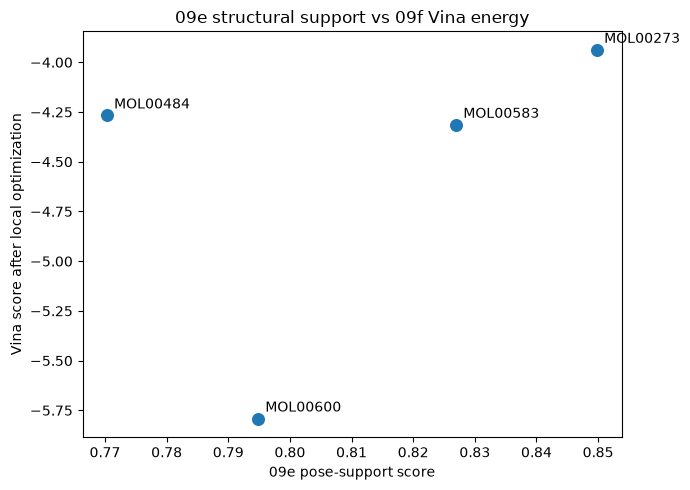

Saved: outputs/pipeline_5_pharmacophore_09f_vina_refinement/plots/09f_pose_support_vs_vina.png


In [17]:
if RUN_EXISTING_VINA_RESULTS_ANALYSIS:
    plot_df = refined_df.sort_values(
        "09f_rank"
    )

    plt.figure(
        figsize=(7, 5)
    )

    plt.scatter(
        plot_df[
            "pose_support_score"
        ],
        plot_df[
            "vina_score_after"
        ],
        s=70,
    )

    for row in plot_df.itertuples():
        plt.annotate(
            row.candidate_id,
            (
                row.pose_support_score,
                row.vina_score_after,
            ),
            xytext=(5, 5),
            textcoords="offset points",
        )

    plt.xlabel(
        "09e pose-support score"
    )

    plt.ylabel(
        "Vina score after local optimization"
    )

    plt.title(
        "09e structural support vs 09f Vina energy"
    )

    plt.tight_layout()

    path = (
        PLOT_DIR
        / "09f_pose_support_vs_vina.png"
    )

    plt.savefig(
        path,
        dpi=250,
        bbox_inches="tight",
    )

    plt.show()

    print(
        "Saved:",
        path,
    )


## 17. Copy / index locally minimized structures

If minimized SDF files were exported, they become the preferred 09f structures for downstream
comparison. Otherwise the minimized PDBQT remains available.


In [18]:
if RUN_EXISTING_VINA_RESULTS_ANALYSIS:
    structure_rows = []

    for row in refined_df.itertuples():
        src_sdf = Path(
            row.minimized_sdf
        )

        src_pdbqt = Path(
            row.minimized_pdbqt
        )

        dst_sdf = (
            STRUCTURE_DIR
            / f"{row.candidate_id}_09f_vina_local_minimized.sdf"
        )

        dst_pdbqt = (
            STRUCTURE_DIR
            / f"{row.candidate_id}_09f_vina_local_minimized.pdbqt"
        )

        sdf_copied = False
        pdbqt_copied = False

        if src_sdf.exists():
            shutil.copy2(
                src_sdf,
                dst_sdf,
            )
            sdf_copied = True

        if src_pdbqt.exists():
            shutil.copy2(
                src_pdbqt,
                dst_pdbqt,
            )
            pdbqt_copied = True

        structure_rows.append({
            "candidate_id": row.candidate_id,
            "sdf_copied": sdf_copied,
            "pdbqt_copied": pdbqt_copied,
            "sdf_path": str(dst_sdf),
            "pdbqt_path": str(dst_pdbqt),
        })

    structure_df = pd.DataFrame(
        structure_rows
    )

    structure_df.to_csv(
        TABLE_DIR
        / "09f_refined_structure_files.csv",
        index=False,
    )

    display(
        structure_df
    )


,candidate_id,sdf_copied,pdbqt_copied,sdf_path,pdbqt_path
0,MOL00600,True,True,outputs/pipeline_5_pharmacophore_09f_vina_refi...,outputs/pipeline_5_pharmacophore_09f_vina_refi...
1,MOL00583,True,True,outputs/pipeline_5_pharmacophore_09f_vina_refi...,outputs/pipeline_5_pharmacophore_09f_vina_refi...
2,MOL00484,True,True,outputs/pipeline_5_pharmacophore_09f_vina_refi...,outputs/pipeline_5_pharmacophore_09f_vina_refi...
3,MOL00273,True,True,outputs/pipeline_5_pharmacophore_09f_vina_refi...,outputs/pipeline_5_pharmacophore_09f_vina_refi...


## 18. Quality control

Technical QC does not require that Vina agree with DiffDock.

Disagreement is a valid scientific result and should be retained.


In [19]:
qc_rows = [
    {
        "check": "09e_QC_passed",
        "pass": bool(
            qc_flags.all()
        ),
    },
    {
        "check": "four_candidates_selected",
        "pass": (
            len(
                selected09f
            )
            == TOP_N_FOR_09F
        ),
    },
    {
        "check": "09e_selected_pose_files_present",
        "pass": bool(
            all(
                Path(p).exists()
                for p in selected09f[
                    "selected_pose"
                ]
            )
        ),
    },
    {
        "check": "vina_manifest_created",
        "pass": manifest_path.exists(),
    },
    {
        "check": "vina_external_script_created",
        "pass": VINA_EXTERNAL_SCRIPT.exists(),
    },
]

if RUN_EXISTING_VINA_RESULTS_ANALYSIS:
    qc_rows.extend([
        {
            "check": "vina_results_complete",
            "pass": (
                len(
                    vina_df
                )
                == TOP_N_FOR_09F
            ),
        },
        {
            "check": "all_vina_scores_finite",
            "pass": bool(
                np.isfinite(
                    refined_df[
                        [
                            "vina_score_before",
                            "vina_score_after",
                        ]
                    ].to_numpy(
                        dtype=float
                    )
                ).all()
            ),
        },
        {
            "check": "pharmacophore_status_preserved",
            "pass": bool(
                (
                    refined_df[
                        "pharmacophore_status"
                    ]
                    == "NEAR_MISS_MANDATORY_ONLY"
                ).all()
            ),
        },
        {
            "check": "docking_track_preserved",
            "pass": bool(
                (
                    refined_df[
                        "docking_track"
                    ]
                    == "NEAR_MISS_RESCUE"
                ).all()
            ),
        },
        {
            "check": "refined_ranking_exported",
            "pass": (
                TABLE_DIR
                / "09f_vina_refined_ranking.csv"
            ).exists(),
        },
    ])

qc_df = pd.DataFrame(
    qc_rows
)

ALL_QC_PASSED = bool(
    qc_df[
        "pass"
    ].all()
)

display(
    qc_df
)

print(
    "ALL QC PASSED:",
    ALL_QC_PASSED,
)

qc_df.to_csv(
    TABLE_DIR
    / "09f_QC.csv",
    index=False,
)


,check,pass
0,09e_QC_passed,True
1,four_candidates_selected,True
2,09e_selected_pose_files_present,True
3,vina_manifest_created,True
4,vina_external_script_created,True
5,vina_results_complete,True
6,all_vina_scores_finite,True
7,pharmacophore_status_preserved,True
8,docking_track_preserved,True
9,refined_ranking_exported,True


ALL QC PASSED: True


## 19. Automatic report


In [21]:
report_lines = [
    "# 09f — Vina Local Rescoring and Interaction Refinement",
    "",
    "## Input",
    f"- 09e candidates available: {len(best09e)}",
    f"- Candidates selected for 09f: {len(selected09f)}",
    "- Selection rule: top four by 09e candidate rank",
    "- Refinement: Vina score + local BFGS optimization of the selected DiffDock pose",
    "- No new global Vina docking search",
    "",
]

if not RUN_EXISTING_VINA_RESULTS_ANALYSIS:
    report_lines.extend([
        "## Status",
        "- Stage A complete.",
        "- Vina/Meeko external execution still required.",
        "",
        f"- Manifest: {manifest_path.resolve()}",
        f"- Run script: {VINA_SHELL_SCRIPT.resolve()}",
    ])

else:
    report_lines.extend([
        "## Vina ranking",
    ])

    for _, row in refined_df.iterrows():
        rmsd = row.get(
            "diffdock_to_vina_local_RMSD_A",
            np.nan,
        )

        rmsd_text = (
            f"{rmsd:.3f} Å"
            if pd.notna(rmsd)
            else "NA"
        )

        report_lines.append(
            (
                f"- {row['candidate_id']} | "
                f"09f rank={int(row['09f_rank'])} | "
                f"09e rank={int(row['09e_candidate_rank'])} | "
                f"Vina before={row['vina_score_before']:.3f} | "
                f"Vina after={row['vina_score_after']:.3f} | "
                f"delta={row['vina_delta_local_optimization']:.3f} | "
                f"local RMSD={rmsd_text}"
            )
        )

    report_lines.extend([
        "",
        "## Interpretation",
        (
            "Vina scores are empirical docking-score outputs and are not rigorous "
            "binding free energies."
        ),
        (
            "The score of the unchanged DiffDock pose tests cross-method agreement; "
            "the locally optimized score tests whether a nearby geometry is energetically "
            "preferred by the Vina scoring function."
        ),
        (
            "A small structural displacement together with improved Vina score provides "
            "stronger cross-method support than a large pose rearrangement."
        ),
        (
            "All 09f candidates remain NEAR_MISS_RESCUE / "
            "NEAR_MISS_MANDATORY_ONLY."
        ),
    ])

report_lines.extend([
    "",
    f"ALL QC PASSED: {ALL_QC_PASSED}",
])

report_text = "\n".join(
    report_lines
)

report_path = (
    REPORT_DIR
    / "09f_vina_refinement_report.md"
)

report_path.write_text(
    report_text,
    encoding="utf-8",
)

print(
    report_text
)

print(
    "\nReport:",
    report_path.resolve(),
)


# 09f — Vina Local Rescoring and Interaction Refinement

## Input
- 09e candidates available: 8
- Candidates selected for 09f: 4
- Selection rule: top four by 09e candidate rank
- Refinement: Vina score + local BFGS optimization of the selected DiffDock pose
- No new global Vina docking search

## Vina ranking
- MOL00600 | 09f rank=1 | 09e rank=3 | Vina before=1.998 | Vina after=-5.791 | delta=-7.789 | local RMSD=0.190 Å
- MOL00583 | 09f rank=2 | 09e rank=2 | Vina before=0.384 | Vina after=-4.314 | delta=-4.698 | local RMSD=0.586 Å
- MOL00484 | 09f rank=3 | 09e rank=4 | Vina before=-0.556 | Vina after=-4.267 | delta=-3.711 | local RMSD=0.057 Å
- MOL00273 | 09f rank=4 | 09e rank=1 | Vina before=-2.982 | Vina after=-3.937 | delta=-0.955 | local RMSD=0.203 Å

## Interpretation
Vina scores are empirical docking-score outputs and are not rigorous binding free energies.
The score of the unchanged DiffDock pose tests cross-method agreement; the locally optimized score tests whether a nearby g

# 20. Final interpretation and next step

When Stage B finishes with `ALL QC PASSED: True`, 09f is complete.

The evidence layers will then be:

```text
09b pharmacophore
09c pharmacophore realization
09d chemistry / drug-likeness
09e DiffDock pose + interface contacts
09f Vina local energetic refinement
```

The final Pipeline-5 notebook should be:

```text
09g — Integrated small-molecule lead selection
```

09g should report **convergence and disagreement across methods**, rather than force every
signal into a single physically unjustified universal score.
